# Множественная проверка гипотез (МПГ)

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as sps
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.notebook import tqdm
from IPython.display import Image, display, clear_output
from statsmodels.stats.proportion import proportion_confint
from statsmodels.stats.multitest import multipletests

from typing import List, Tuple, Callable, Any, Dict, Union

sns.set(font_scale=1.2, palette="Set2", style="whitegrid")

In [2]:
SEED = 123
np.random.seed(SEED)

## 1. Напоминание теории

Представим себе, что мы проводим 6 тестов с соответствующими нулевыми гипотезами $\mathsf{H}_{1}, ..., \mathsf{H}_{{6}}$, каждый из которых имеет уровень значимости $\alpha = 0.05$. С какой вероятностью мы отвергнем хотя бы одну из них в пользу соответствующей альтернативной, даже **если они все верны**?

$$\mathsf{P}(\text{не совершить ош. I рода в при проверке }\mathsf{H}_j) = 1-\alpha$$

$$\mathsf{P}(\text{не совершить НИ ОДНОЙ ош. I рода}) = (1-\alpha)^{6}\big|_{\alpha=0.05} = 0.95^{6} \approx 0.735$$

И тогда $$\mathsf{P}(\text{совершить ХОТЯ БЫ ОДНУ ош. I рода}) = 1 - (1-\alpha)^{6}\big|_{\alpha=0.05} = 1 - 0.95^{6} \approx 0.265$$

То есть с вероятностью около 26.5% мы неверно отвергнем нулевую гипотезу по воле случая.

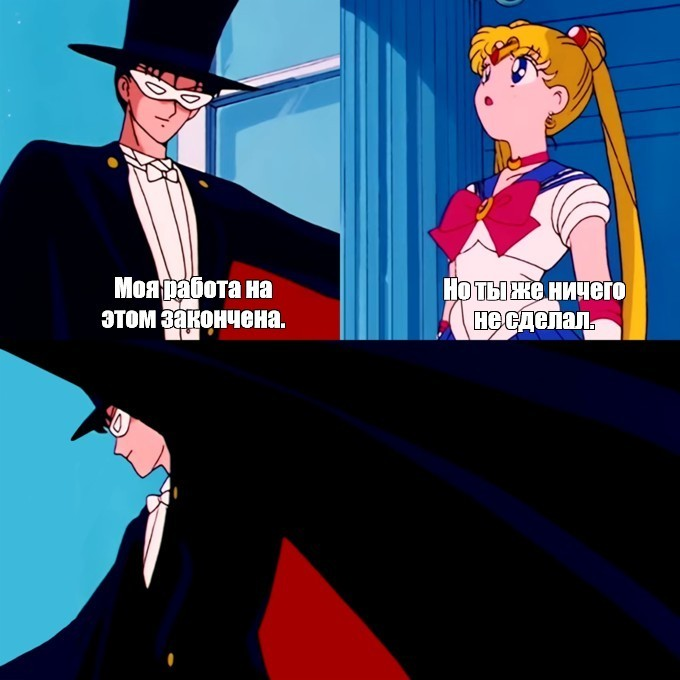





Кажется, мы "немного" превысили допустимую долю ошибок I рода. Что делать?


Представим, что в общем случае мы **тестируем $m$ гипотез**, при этом (откуда-то) знаем, что $m_0$ из них верны, а $m-m_0=m_1$ неверны.


### 1.1 FWER (familywise error rate, групповая вероятность ошибки I рода)

$$FWER = \mathsf{P}(V_{\mathsf{P} S} \geq 1),$$
где $V_{\mathsf{P} S}$ — количество верных гипотез, которые были отвергнуты
критерием $S$ для распределения $P$ (задает верные гипотезы).

Как обеспечить $FWER < \alpha$?

*   Метод Бонферрони
    
    Каждый критерий имеет уровень значимости $\alpha_j = \frac{\alpha}{m}$

*   Метод Холма
    
    * Пересортируем гипотезы и критерии в порядке возрастания p-value:

        $p_\text{(1)} \leqslant ... \leqslant p_\text{(m)}$ &mdash; p-value

        $\mathsf{H}\_\text{(1)}, ..., \mathsf{H}_\text{(m)}$ &mdash; соответствующие гипотезы

    * $\alpha_j = \frac{\alpha}{m-j+1}$ &mdash; уровень значимости критерия $S_j$  

    * Пусть $j$   &mdash; номер первой неотвергнутой гипотезы
        
        
        $\Rightarrow$ отвергаем гипотезы $\mathsf{H}\_1, ..., \mathsf{H}_{j-1}$.


### 1.2 FDR (false discovery rate, ожидаемая доля ложных отклонений)

Вместо того чтобы контролировать вероятность хотя бы одного ложноположительного результата (как FWER), FDR контролирует **ожидаемую долю ложноположительных результатов** среди всех значимых результатов. Если мы получим 10 значимых результатов при значении FDR, равном 5%, получится что $10 \cdot 0.05=0.5$ из них в среднем (!) являются ложноположительными.

$$\text{FDR} = \mathsf{E}_{\mathsf{P}} \frac{V_{\mathsf{P} S}}{\max(R_S, 1)},$$
где $V_{\mathsf{P} S}$ &mdash; количество верных гипотез, которые были отвергнуты, а $R_S$ &mdash; количество отвергнутых гипотез.


* Пересортируем гипотезы и критерии в порядке возрастания p-value.

    $p_1 \leqslant ... \leqslant p_m$ &mdash; p-value

    $\mathsf{H}_1, ..., \mathsf{H}_m$ &mdash; соответствующие гипотезы

* Метод Бенджамини-Хохберга (если статистики критериев независимы):

    $\alpha_j = \frac{\alpha j}{m}$

* Метод Бенджамини-Иекутиели:

    $\alpha_j = \frac{\alpha j}{m} \left/ \sum_{j=1}^m 1/j \right.$

* Пусть $j = \max\{ j\ |\ p_j \leqslant \alpha_j \}$  &mdash; номер последней отвергнутой гипотезы

    $\Rightarrow$ отвергаем гипотезы $\mathsf{H}_1, ..., \mathsf{H}_j$.



## 2. МПГ на примере клинических испытаний

Посмотрим, как на практике работают разные методы контроля ошибки первого рода.

**Суть эксперимента**

> Некая фармацевтическая компания проводит рандомизированное двойное слепое плацебо-контролируемое клиническое исследование III фазы. Их цель &mdash; **оценить эффективность нового лекарственного средства *Препарат-A* при хроническом заболевании**. Из-за сложного характера этого заболевания, схема исследования включает несколько альтернативных первичных бинарных конечных точек ($E_1 - E_6 $).
>
> В исследовании приняли участие $n=500$ пациентов:
> * $n_T = 250$ в группе тестирования Препарата-А
> * $n_P = 250$ в группе плацебо.

**Эффект**

> для признания препарата эффективным необходим статистически значимый положительный эффект (превосходство над плацебо) по крайней мере в отношении одной из этих основных конечных точек.

Альтернативные первичные конечные точки:  
| Индекс Конечной Точки | Клиническое Измерение | Определение Конечной Точки | Нулевая Гипотеза ($H_j$) |
| :--- | :--- | :--- | :--- |
| **E₁** | Снижение Симптомов | Доля пациентов, достигших **≥ 50%** снижения оценки тяжести симптомов к Неделе 12 | $p_{T_1} = p_{P_1}$ |
| **E₂** | Глубокая Ремиссия | Доля пациентов, достигших полной ремиссии (согласно стандартному клиническому индексу) к Неделе 12 | $p_{T_2} = p_{P_2}$  |
| **E₃** | Стабильность Заболевания | Доля пациентов, не имеющих острых обострений заболевания к Неделе 12 | $p_{T_3} = p_{P_3}$  |
| **E₄** | Качество Жизни Пациента (PRO) | Доля пациентов, сообщивших о 'Минимально Клинически Значимой Разнице' в оценке качества жизни к Неделе 12 | $p_{T_4} = p_{P_4}$  |
| **E₅** | Устойчивая Эффективность | Доля пациентов, свободных от рецидивов/повторных симптомов в период между Неделей 12 и Неделей 24 | $p_{T_5} = p_{P_5}$  |
| **E₆** | Функциональная Способность | Доля пациентов, достигших нормальной функциональной способности к Неделе 12 | $p_{T_6} = p_{P_6}$  |

Для каждой конечной точки $E_k, k \in \{1..6\}$ проводится проверка статистических гипотез  

$$\mathsf{H}_{j} \colon p_{T_j} - p_{P_j} \leq 0$$
$$\mathsf{H}_{j}^*\colon p_{T_j} - p_{P_j} > 0$$

с помощью критерия Вальда, для которого статистика критерия рассчитывается по формуле:

$$W_j = \frac{\widehat{p}_{T_j} - \widehat{p}_{P_j}}{\sqrt{\frac{\widehat{p}_{P_j}\left(1-\widehat{p}_{P_j}\right)}{n_T} + \frac{\widehat{p}_{T_j}\left(1-\widehat{p}_{T_j}\right)}{n_P}}}$$



Таким образом, мы проводим 6 статистических тестов и вероятность допустить хотя бы одно ложное отвержение повышается до $1 - 0.95^{6} \approx 0.265$

In [3]:
ALPHA = 0.05  # целевой уровень значимости

Данные о результатах эксперимента содержат колонки:

*   `Конечная Точка` &mdash; id конечной точки исследования,
*   `Успехи_Плацебо` &mdash; сколько из $n_P = 250$ человек показали эффект в конечной точке в группе приема Плацебо,
*   `Успехи_Перпарат-А` &mdash; сколько из $n_T = 250$ человек показали эффект в конечной точке в группе приема Препарата-А,
*   `P_Плацебо` &mdash; **неизвестное исследователю** значение среднего числа ответчиков в группе Плацебо,
*   `P_Препарат-A` &mdash; **неизвестное исследователю** значение среднего числа ответчиков в группе Препарат-А,
*   `Истинная Разница` &mdash; **неизвестная исследователю** величина (`P_Препарат-A` $-$ `P_Плацебо`).


In [4]:
df = pd.read_csv("AB_CT_6_endpoints.tsv", sep="\t")
df

,Конечная_точка,Успехи_Плацебо,Успехи_Препарат-A,P_Плацебо,P_Препарат-A,Истинная_разница
0,E1,20,61,0.10,0.27,0.17
1,E2,109,127,0.42,0.49,0.07
2,E3,35,51,0.15,0.22,0.07
3,E4,145,126,0.55,0.53,-0.02
4,E5,64,82,0.25,0.37,0.12
5,E6,158,148,0.60,0.60,0.00


In [5]:
ALPHA = 0.05

Для проведения сравнения долей ответчиков в экспериментальной и контрольной группах будем использовать критерий Вальда для сравнения пропорций.

In [6]:
def wald_right_proportion_test(
    control_resp: int, control_n: int, exp_resp: int, exp_n: int
) -> Tuple[float, float, float, float]:
    """
    Вычисляет статистику и p-value для правостороннего теста Вальда
    сравнения двух пропорций.

    Аргументы:
        control_resp: Количество ответчиков на терапию в контрольной группе
        control_n: Количество участников в контрольной группе
        exp_resp: Количество ответчиков на терапию в экспериментальной группе
        exp_n: Количество участников в экспериментальной группе

    Возвращает:
        Кортеж из элементов:
        - stat: Значение Z-статистики теста Вальда
        - p_value: Рассчитанное p-value для правостороннего теста
        - p_control: Доля успехов в контрольной группе
        - p_exp: Доля успехов в экспериментальной группе
    """
    # расчет пропорций
    p_control = control_resp / control_n
    p_exp = exp_resp / exp_n

    # расчет дисперсий
    var_control = p_control * (1 - p_control) / control_n
    var_exp = p_exp * (1 - p_exp) / exp_n

    # стандартное отклонение для статистики Вальда
    SE = np.sqrt(var_control + var_exp)

    if SE == 0:
        stat = 0.0
    else:
        stat = (p_exp - p_control) / SE

    p_value = 1 - sps.norm.cdf(stat)

    return stat, p_value, p_control, p_exp

In [7]:
endpoints = [f"E{i}" for i in range(1, 7)]  # id конечных точек
n_T = 250  # объем выборки для группы Препарат-A
n_P = 250  # объем выборки для группы Плацебо
results = []

for i, row in df.iterrows():
    stat, p_value_raw, p_control, p_exp = wald_right_proportion_test(
        control_resp=row["Успехи_Плацебо"],
        control_n=n_P,
        exp_resp=row["Успехи_Препарат-A"],
        exp_n=n_T,
    )

    results.append(
        {
            "Конечная Точка": endpoints[i],
            "Доля успехов Плацебо": p_control,
            "Доля успехов Препарат-A": p_exp,
            "Z_Статистика": stat,
            "p_value_raw": p_value_raw,
            "reject_raw": p_value_raw < ALPHA,
        }
    )

results_df = pd.DataFrame(results).sort_values(by="p_value_raw")
results_df["Всего участников"] = n_T + n_P

print("p-value без поправок (по возрастанию) \n")
display(results_df[["Конечная Точка", "Z_Статистика", "p_value_raw", "reject_raw"]])

p-value без поправок (по возрастанию) 



,Конечная Точка,Z_Статистика,p_value_raw,reject_raw
0,E1,5.104464,1.658668e-07,True
2,E3,1.902929,2.852491e-02,True
4,E5,1.776008,3.786577e-02,True
1,E2,1.616708,5.297061e-02,False
5,E6,-0.918522,8.208272e-01,False
3,E4,-1.710421,9.564060e-01,False


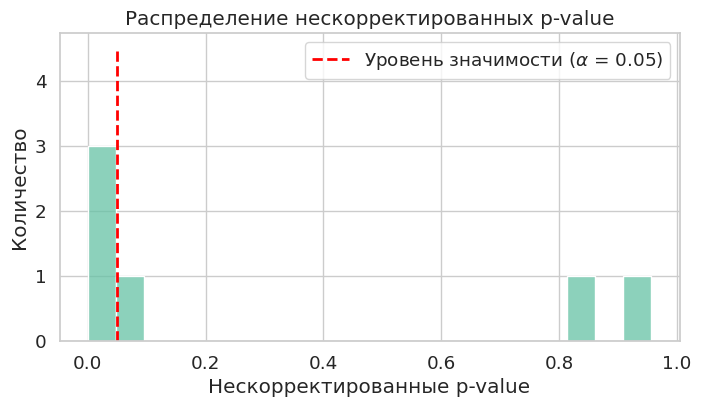

In [8]:
plt.figure(figsize=(8, 4))
sns.histplot(results_df["p_value_raw"], bins=20)
plt.vlines(
    x=ALPHA,
    ymin=0,
    ymax=4.5,
    color="red",
    linestyles="--",
    lw=2,
    label=f"Уровень значимости ($\\alpha$ = {ALPHA})",
)
plt.title("Распределение нескорректированных p-value")
plt.xlabel("Нескорректированные p-value")
plt.ylabel("Количество")
plt.yticks(range(0, 5))
plt.legend()
plt.show()

Для проведения процедуры корректировки p-value в случае множественной проверки гипотез не нужно самостоятельно высчитывать пороги $\alpha$ для каждой гипотезы, для этого в библиотеке `statsmodels` есть метод `multipletests`: `from statsmodels.stats.multitest import multipletests`

Аргументы:


*  `pvals` &mdash; нескорректированные ("сырые") p-value, обязательно одномерный массив.

* `alpha` &mdash; гарантируемый уровень значимости, например, 0.05 или 0.1

* `method` &mdash; метод, который будет использоваться для введения поправок на множественное сравнение

    * `'bonferroni'`
    * `'holm'`
    * `'fdr_bh'`
    * `'fdr_by'`

* `is_sorted` &mdash; массив pvals отсортирован пользователем, по дефолту False
* `returnsorted` &mdash; возвращать отсортированный по возрастанию массив скорректированных p-value, по дефолту False и возвращает в том же порядке, что и pvals

Возвращает:

* `reject` &mdash; True для соответствующего скорректированного p-value, если при заданном уровне значимости нулевая гипотеза отвергается

* `pvals_corrected` &mdash; скорректированные соответствующим методом значения p-value

* еще 2 возвращаемых значения нам не пригодятся


In [9]:
methods = {"bonferroni": "bonf", "holm": "holm", "fdr_bh": "bh", "fdr_by": "by"}

p_adj_cols = []
for method_name, suffix in methods.items():

    # Применение процедуры МПГ
    reject, p_adj, _, _ = multipletests(results_df["p_value_raw"], alpha=ALPHA, method=method_name)

    results_df[f"p_adj_{suffix}"] = p_adj
    results_df[f"reject_{suffix.capitalize()}"] = reject
    p_adj_cols.append(f"p_adj_{suffix}")


print("Cкорректированные p-value (по возрастанию)")
summary_cols = ["Конечная Точка", "p_value_raw"] + p_adj_cols
display(results_df[summary_cols])

Cкорректированные p-value (по возрастанию)


,Конечная Точка,p_value_raw,p_adj_bonf,p_adj_holm,p_adj_bh,p_adj_by
0,E1,1.658668e-07,9.952006e-07,9.952006e-07,9.952006e-07,0.000002
2,E3,2.852491e-02,1.711495e-01,1.426246e-01,7.573154e-02,0.185542
4,E5,3.786577e-02,2.271946e-01,1.514631e-01,7.573154e-02,0.185542
1,E2,5.297061e-02,3.178237e-01,1.589118e-01,7.945591e-02,0.194667
5,E6,8.208272e-01,1.000000e+00,1.000000e+00,9.564060e-01,1.000000
3,E4,9.564060e-01,1.000000e+00,1.000000e+00,9.564060e-01,1.000000


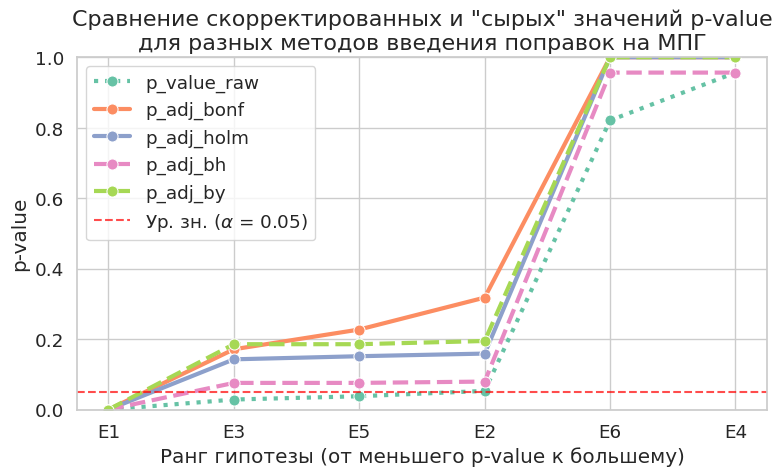

In [10]:
p_plot_df = results_df.reset_index(drop=True).reset_index().rename(columns={"index": "rank"})
p_plot_df_long = p_plot_df.melt(
    id_vars=["rank", "Конечная Точка"],
    value_vars=["p_value_raw", "p_adj_bonf", "p_adj_holm", "p_adj_bh", "p_adj_by"],
    var_name="correction method",
    value_name="p_value",
)

style_map = {
    "p_adj_bonf": "-",
    "p_adj_holm": "-",
    "p_adj_bh": "--",
    "p_adj_by": "--",
    "p_value_raw": ":",
}

plt.figure(figsize=(8, 5))
for method in p_plot_df_long["correction method"].unique():
    subset = p_plot_df_long[p_plot_df_long["correction method"] == method]

    sns.lineplot(
        data=subset,
        x="Конечная Точка",
        y="p_value",
        label=method,
        linestyle=style_map.get(method, "-"),
        marker="o",
        markersize=8,
        lw=3,
    )

plt.axhline(ALPHA, ls="--", color="red", alpha=0.7, label=f"Ур. зн. ($\\alpha$ = {ALPHA})")
plt.title(
    'Сравнение скорректированных и "сырых" значений p-value\nдля разных методов введения поправок на МПГ',
    fontsize=16,
)
plt.xlabel("Ранг гипотезы (от меньшего p-value к большему)")
plt.xticks(sorted(p_plot_df_long["rank"].unique()))
plt.ylabel("p-value")
plt.legend(loc="upper left")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [11]:
reject_cols = [
    "Конечная Точка",
    "reject_raw",
    "reject_Bonf",
    "reject_Holm",
    "reject_Bh",
    "reject_By",
]
display(results_df[reject_cols])

,Конечная Точка,reject_raw,reject_Bonf,reject_Holm,reject_Bh,reject_By
0,E1,True,True,True,True,True
2,E3,True,False,False,False,False
4,E5,True,False,False,False,False
1,E2,False,False,False,False,False
5,E6,False,False,False,False,False
3,E4,False,False,False,False,False


**Выводы**

* Без корректировки p-value мы бы отвергли 3 нулевых гипотезы о неэффективности Препарата-А.<br/><br/>


* **После корректировки с контролем FWER** методами Бонферрони и Холма мы отвергаем только 1 гипотезу: о неэффективности препарата относительно снижения оценки тяжести симптомов на ≥ 50%  к Неделе 12 (контрольная точка 1).

    Гипотезы о неэффективности относительно возникновения острых обострений заболевания к Неделе 12 (контрольная точка 3) и рецидивов/повторных симптомов в период между Неделей 12 и Неделей 24 (контрольная точка 5) отвергнуты быть не могут.<br/><br/>


* **Если бы нас интересовал контроль FDR**, то и метод Бенджамини-Хохберга и метод Бенджамини-Иекутиели тоже отвергли бы только 1 гипотезу в контрольной точке 1.


## Планирование экспериментов

Стоит отметить, что выбираем подход к корректировке p-value мы не столько из знаний о мощности итогового теста, сколько из знаний, когда те или иные поправки применять корректно.



### 1.   Когда применять множественную проверку гипотез?
    
Этот вопрос стоит самым первым. Cхема "мы провели много тестов, поэтому нам нужна МПГ" не всегда работает. Важна **цель исследования**, на какой вопрос мы хотим ответить.

> В нашем случае, когда проверяем много гипотез и считаем препарат эффективных, когда хотя бы одна из них верна, **критически важен контроль ошибок I рода**.
> При этом если нулевые гипотезы никак не пересекаются, мы не собираемся объединять результаты в общий вывод, то **МПГ нет**, а значит и поправки не нужны.
>
> С аналогичной ситуацией мы сталкиваемся в **post hoc анализе**: сначала проводим тест "есть ли хоть одна группа, которая отличается от других", а потом делаем множество попарных сравнений.


### 2.   FWER или FDR?

Выбор между контролем FWER или FDR не относится к статистике, а зависит от задач, которые стоят перед исследователем.

**FWER**:
* Выбирайте его, если цена одного ложного срабатывания **чрезвычайно** высока.

    Аналогия: клинические испытания. Выбор ложно эффективного препарата приведет к многомиллионным убыткам фармацевтической компании.<br/><br/>

* Обычно $\alpha = 0.05$ или $0.01$<br/>
    
**FDR**:

* Выбирайте его, если вам нужно **найти как можно больше истинных эффектов из $m_1$ существующих и стоимость ложноположительных срабатываний невелика**, а польза от истинного положительного результата высока.
    
    Аналогия: скрининговое исследование лекарств. Мы хотим найти все перспективные соединения среди огромного списка, который нам предложила LLM. И готовы признать, что первоначальный "многообещающий" список из 50 соединений может содержать 2-3 ложноположительных результата, но мы их отфильтруем в более поздних (и более дорогостоящих) исследованиях.<br/><br/>


* Обычно $\alpha = 0.10$ (иногда допустимо и больше) при поиске кандидатов для следующих этапов прицельного изучения.


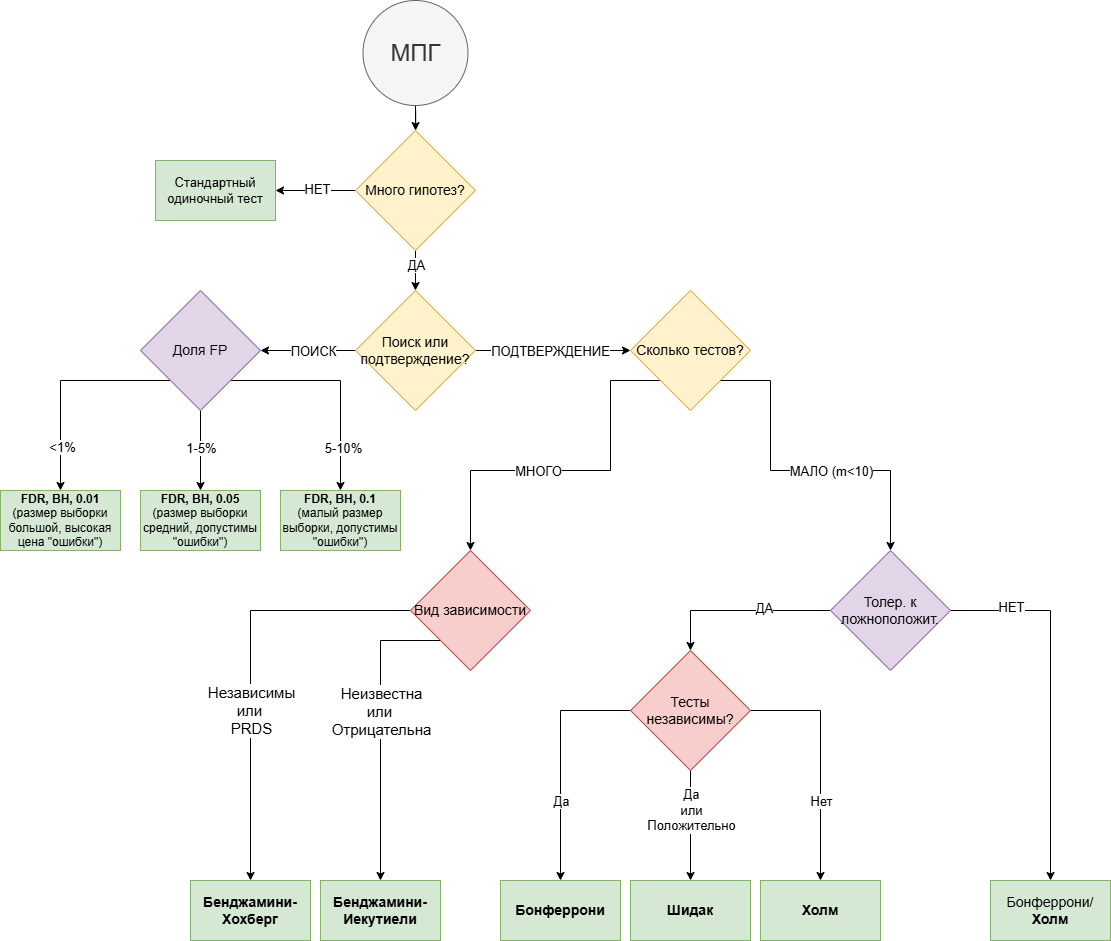

---
© 2025 команда <a href="https://thetahat.ru/">ThetaHat</a> для DS-потока